In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


# Manual Gradient Calculation in Numpy

In [ ]:
import numpy as np
# Simple function f(x) = x^2
def f(x):
    return x ** 2

# Manual derivative (f’(x) = 2x)
def gradient(x):
    return 2 * x

# Update rule: x = x - learning_rate * gradient
x = 5.0
learning_rate = 0.1
for _ in range(10): # Manually optimize for 10 steps
    x -= learning_rate * gradient(x)
    print(f"x: {x}, f(x): {f(x)}")

x: 4.0, f(x): 16.0
x: 3.2, f(x): 10.240000000000002
x: 2.56, f(x): 6.5536
x: 2.048, f(x): 4.194304
x: 1.6384, f(x): 2.68435456
x: 1.31072, f(x): 1.7179869184000003
x: 1.0485760000000002, f(x): 1.0995116277760004
x: 0.8388608000000002, f(x): 0.7036874417766403
x: 0.6710886400000001, f(x): 0.45035996273704976
x: 0.5368709120000001, f(x): 0.2882303761517119


# Gradient Computations with Keras.

In [ ]:
import tensorflow as tf
x = tf.Variable(5.0) # Trainable variable
with tf.GradientTape() as tape:
  y = x ** 2 # y = x^2
  grad = tape.gradient(y, x) # Computes dy/dx automatically
  print(grad.numpy()) # Output: 10.0

10.0


# Matrix Multiplication Speed (Numpy vs. Tensorflow on GPU).

In [ ]:
import numpy as np
import tensorflow as tf
import time
# Create large random matrices
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)
# NumPy Multiplication
start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)
# TensorFlow Multiplication (for colab uses GPU Runtime if available)
A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.10412192344665527
TensorFlow Time: 0.1718447208404541


# Implementation of Activation Function with Keras.

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

# Manually Training Network in Numpy.

In [ ]:
import numpy as np

# Initialize placeholder data and weights for demonstration
x_train = np.array([[1.0], [2.0], [3.0], [4.0]]) # Example input data
y_train = np.array([[2.0], [4.0], [6.0], [8.0]]) # Example target data (e.g., y = 2*x)
weights = np.array([[0.1]]) # Initial weights
learning_rate = 0.01 # Learning rate (already defined in kernel, but good to have explicit here)

for epoch in range(10):
    # Forward pass
    y_pred = np.dot(x_train, weights)
    # Compute loss
    loss = np.mean((y_pred - y_train) ** 2)
    # Compute gradients manually
    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)
    # Update weights
    weights -= learning_rate * gradients
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Weights: {weights.flatten()[0]:.4f}")

Epoch 1, Loss: 27.0750, Weights: 0.3850
Epoch 2, Loss: 19.5617, Weights: 0.6273
Epoch 3, Loss: 14.1333, Weights: 0.8332
Epoch 4, Loss: 10.2113, Weights: 1.0082
Epoch 5, Loss: 7.3777, Weights: 1.1570
Epoch 6, Loss: 5.3304, Weights: 1.2834
Epoch 7, Loss: 3.8512, Weights: 1.3909
Epoch 8, Loss: 2.7825, Weights: 1.4823
Epoch 9, Loss: 2.0103, Weights: 1.5599
Epoch 10, Loss: 1.4525, Weights: 1.6259


# keras training is One Line.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define a simple Keras model (e.g., a single dense layer for linear regression)
model = Sequential([
    Dense(1, input_shape=(1,))
])

# Compile the model (specify optimizer, loss function, and metrics)
model.compile(optimizer='adam', loss='mse')

# Now, fit the model to the data
model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 610ms/step - loss: 61.0582
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 61.0012
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 60.9441
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 60.8871
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 60.8302
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 60.7732
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 60.7163
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 60.6594
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 60.6026
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 60.5458


# Layers in Keras.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
Dense(64, activation='relu', input_shape=(784,)),
Dense(10, activation='softmax')
])

# Implementing SGD in Numpy.

In [ ]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100): # Training loop
  gradient = np.random.randn(3, 3) # Fake gradient for illustration
  weights -= learning_rate * gradient

# In Keras.

In [ ]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

# Suntax of Dense Layer.

In [ ]:
from tensorflow.keras.layers import Dense

units = 32 # Define units as an integer, for example, 32
layer = Dense(units, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

# A Dense Layer with 64 Neurons and sigmoid Activation.

In [ ]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation="sigmoid") # 64 neurons with sigmoid activation

# Loading and Preprocessing Data with PIL.

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3011, 28, 28, 1), Labels: (3011, 10)


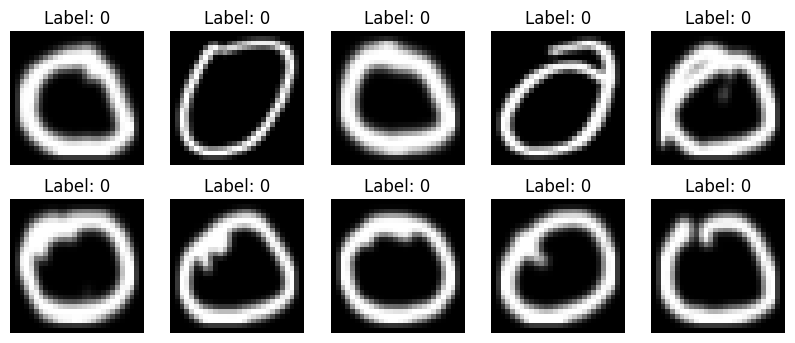

In [18]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths
train_dir = "/content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L") # Convert to grayscale
            img = img.resize((img_width, img_height)) # Resize to (28,28)
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.show()

# Compatibility check for Grayscale Image:

In [25]:
x_train = x_train.reshape(-1, img_height, img_width, 1)
# Use with Cautions.

# Compatibility check for RGB Image:

In [27]:
import numpy as np

# The original x_train has a shape of (num_samples, img_height, img_width, 1).
# To make it compatible with a 3-channel (RGB) input, we repeat the single channel three times.
x_train = np.repeat(x_train, 3, axis=-1)

# Now, x_train has been transformed to have 3 channels.
print(f"x_train shape after RGB compatibility conversion: {x_train.shape}")

x_train shape after RGB compatibility conversion: (60000, 2352)


# Loading and Preprocessing MNIST Handwritten Digit Dataset:

In [40]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize the images to values between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0
# Reshape 28x28 images to include a channel dimension (1 for grayscale)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
# One-hot encode the labels (0-9) for classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Sequential API

In [28]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

# Syntax Model Summary

In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Functional API

In [31]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)
def build_functional_model():
    # Input layer
    inputs = keras.Input(shape=input_shape)
    # Flatten layer
    x = keras.layers.Flatten()(inputs)
    # Hidden layers
    x = keras.layers.Dense(64, activation="sigmoid")(x)
    x = keras.layers.Dense(128, activation="sigmoid")(x)
    x = keras.layers.Dense(256, activation="sigmoid")(x)
    # Output layer
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)
    # Create model
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model
# Build the model
functional_model = build_functional_model()
functional_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Syntax of model.compile()

In [37]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# Syntax of fit() function.

In [44]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28, 28, 1)

# Redefine the model to ensure a fresh state
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

# Recompile the model
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

batch_size = 128
epochs = 2000
# Callbacks
callbacks = [
keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]

# Convert y_train to sparse (integer) labels for sparse_categorical_crossentropy
y_train_sparse = np.argmax(y_train, axis=1)

# Train the model with callbacks and validation split
history = model.fit(
x_train,
y_train_sparse, # Use the sparse labels here
batch_size=batch_size,
epochs=epochs,
validation_split=0.15,
callbacks=callbacks,
)

Epoch 1/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6999 - loss: 0.9952 - val_accuracy: 0.9082 - val_loss: 0.3371
Epoch 2/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9149 - loss: 0.3009 - val_accuracy: 0.9330 - val_loss: 0.2226
Epoch 3/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9368 - loss: 0.2165 - val_accuracy: 0.9498 - val_loss: 0.1744
Epoch 4/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9487 - loss: 0.1734 - val_accuracy: 0.9579 - val_loss: 0.1453
Epoch 5/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9567 - loss: 0.1437 - val_accuracy: 0.9618 - val_loss: 0.1300
Epoch 6/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9627 - loss: 0.1232 - val_accuracy: 0.9623 - val_loss: 0.1271
Epoch 7/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9685 - loss: 0.1056 - val_accuracy: 0.9668 - val_loss: 0.1094
Epoch 8/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9728 - loss: 0.0928 - 

# Sample Code for visualizing Model’s Training Progress.

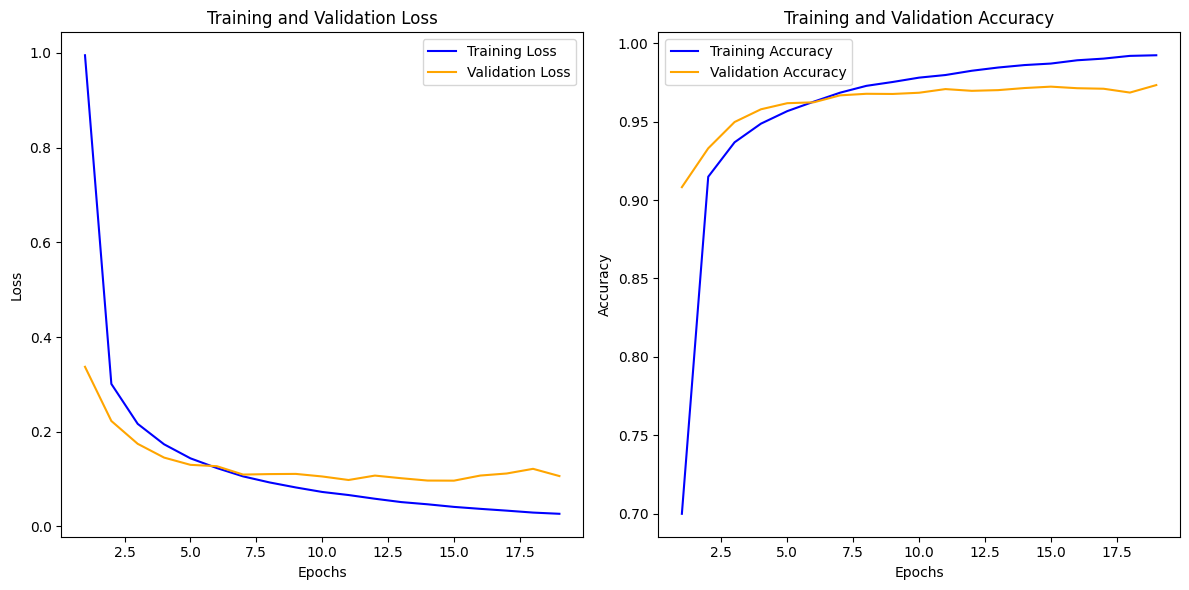

In [47]:
import matplotlib.pyplot as plt
# Assuming ’history’ is the object returned by model.fit()
# Extracting training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
# Extracting training and validation accuracy (if metrics were specified)
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
# Plotting training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Syntax for model.evaluate()

In [52]:
import numpy as np

y_test_sparse = np.argmax(y_test, axis=1)
test_loss, test_acc = model.evaluate(x_test, y_test_sparse, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.9732 - loss: 0.1112
Test accuracy: 0.9732


# Example code for model.predict()

In [53]:
# Predict on test data
predictions = model.predict(x_test)
# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 7
True label for first image: 7


# Saving the Model

In [55]:
model.save('mnist_fully_connected_model.h5')

# Loading the Model

In [56]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')

# Task 1: Data Preparation

In [77]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# --- Task 1: Data Preparation ---
def load_devnagari_data(data_dir):
    images = []
    labels = []
    # Assuming folders are named digit_0, digit_1, ..., digit_9 within train/test directories
    print(f"Loading data from: {data_dir}")
    for label in range(10):
        # Correctly form the path for 'digit_X' folders
        path = os.path.join(data_dir, f'digit_{label}')
        if not os.path.exists(path):
            print(f"Warning: Class folder {path} not found. Skipping.")
            continue
        print(f"Processing folder: {path}")

        for img_file in os.listdir(path):
            try:
                img = Image.open(os.path.join(path, img_file)).convert('L') # Grayscale
                img = img.resize((28, 28)) # Resize to (28,28)
                img_array = np.array(img) / 255.0  # Normalize to 0-1
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_file} from {path}: {e}")

    print(f"Finished loading from {data_dir}. Total images: {len(images)}")
    return np.array(images), np.array(labels)

# Load datasets (Replace with your actual folder paths)
X_train, y_train = load_devnagari_data('/content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train')
X_test, y_test = load_devnagari_data('/content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test')

# Print shapes after initial loading
print(f"Shape of X_train after loading: {X_train.shape}")
print(f"Shape of X_test after loading: {X_test.shape}")

# Flatten images for FCN (28x28 -> 784)
X_train = X_train.reshape((-1, 28 * 28))
X_test = X_test.reshape((-1, 28 * 28))

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Print shapes after flattening and one-hot encoding
print(f"Shape of X_train after flattening: {X_train.shape}")
print(f"Shape of X_test after flattening: {X_test.shape}")
print(f"Shape of y_train_cat: {y_train_cat.shape}")
print(f"Shape of y_test_cat: {y_test_cat.shape}")

# --- Visualization ---
# The history object is not available here yet, this will cause an error if run without training first.
# I will comment it out as the task explicitly asks to re-execute cells after fixing the data loading.
# This visualization will be valid after the model is trained in subsequent steps.

# plt.figure(figsize=(12, 4))

# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train Accuracy')
# plt.plot(history.history['val_accuracy'], label='Val Accuracy')
# plt.title('Accuracy over Epochs')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Val Loss')
# plt.title('Loss over Epochs')
# plt.legend()

# plt.show()


Loading data from: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_0
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_1
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_2
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_3
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_4
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_5
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train/digit_6
Processing folder: /content/drive/MyDrive/Copy of devnagari digit/DevanagariHandwrittenDigitData

## --- Task 2: Build the FCN Model ---

In [78]:

model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(64, activation='sigmoid'),  # 1st Hidden Layer
    layers.Dense(128, activation='sigmoid'), # 2nd Hidden Layer
    layers.Dense(256, activation='sigmoid'), # 3rd Hidden Layer
    layers.Dense(10, activation='softmax')   # Output Layer
])



# --- Task 3: Compile the Model

In [79]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Using categorical because we one-hot encoded
    metrics=['accuracy']
)



# --- Task 4: Train the Model ---

In [80]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_devnagari_model.h5', save_best_only=True)
]

history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2679 - loss: 2.0265

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4599 - loss: 1.6546 - val_accuracy: 0.0000e+00 - val_loss: 7.8843
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8324 - loss: 0.5499 - val_accuracy: 0.0000e+00 - val_loss: 9.2990
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9182 - loss: 0.2845 - val_accuracy: 0.0000e+00 - val_loss: 10.0264
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9413 - loss: 0.2004 - val_accuracy: 0.0000e+00 - val_loss: 10.3657


# --- Task 5: Evaluate the Model ---

In [81]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6058 - loss: 2.2548

Final Test Accuracy: 0.6058


# --- Task 6: Save and Load the Model ---

In [82]:
model.save('devnagari_fcn_model.h5')
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model saved and reloaded successfully.")

Model saved and reloaded successfully.


# --- Task 7: Predictions ---

In [83]:
predictions = loaded_model.predict(X_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print(f"Sample Predictions: {predicted_labels}")
print(f"Actual Labels: {y_test[:5]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Sample Predictions: [0 7 0 0 0]
Actual Labels: [0 0 0 0 0]
